# Import Library

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np

# Load Dataset

In [3]:
data = pd.read_csv('JumlahDesa.csv', index_col=0)
data

,id_index,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,periode_update,kategori,jumlah,satuan,tahun
id,,,,,,,,,,
1,5,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2019,TERTINGGAL,8,DESA,2019
1,4,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2019,SANGAT TERTINGGAL,0,DESA,2019
1,2,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2019,MAJU,24,DESA,2019
1,1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2019,BERKEMBANG,249,DESA,2019
1,3,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2019,MANDIRI,0,DESA,2019
...,...,...,...,...,...,...,...,...,...,...
305,1335,35,JAWA TIMUR,3579,KOTA BATU,2024,TERTINGGAL,0,DESA,2024
305,1331,35,JAWA TIMUR,3579,KOTA BATU,2024,BERKEMBANG,0,DESA,2024
305,1332,35,JAWA TIMUR,3579,KOTA BATU,2024,MAJU,0,DESA,2024


# check missing value

In [4]:
data.isnull().sum()

id_index               0
kode_provinsi          0
nama_provinsi          0
kode_kabupaten_kota    0
nama_kabupaten_kota    0
periode_update         0
kategori               0
jumlah                 0
satuan                 0
tahun                  0
dtype: int64

# Handling Missing Value

In [5]:
data.fillna(data.mean(numeric_only=True), inplace=True)
data

,id_index,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,periode_update,kategori,jumlah,satuan,tahun
id,,,,,,,,,,
1,5,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2019,TERTINGGAL,8,DESA,2019
1,4,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2019,SANGAT TERTINGGAL,0,DESA,2019
1,2,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2019,MAJU,24,DESA,2019
1,1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2019,BERKEMBANG,249,DESA,2019
1,3,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2019,MANDIRI,0,DESA,2019
...,...,...,...,...,...,...,...,...,...,...
305,1335,35,JAWA TIMUR,3579,KOTA BATU,2024,TERTINGGAL,0,DESA,2024
305,1331,35,JAWA TIMUR,3579,KOTA BATU,2024,BERKEMBANG,0,DESA,2024
305,1332,35,JAWA TIMUR,3579,KOTA BATU,2024,MAJU,0,DESA,2024


# EDA Timeseries

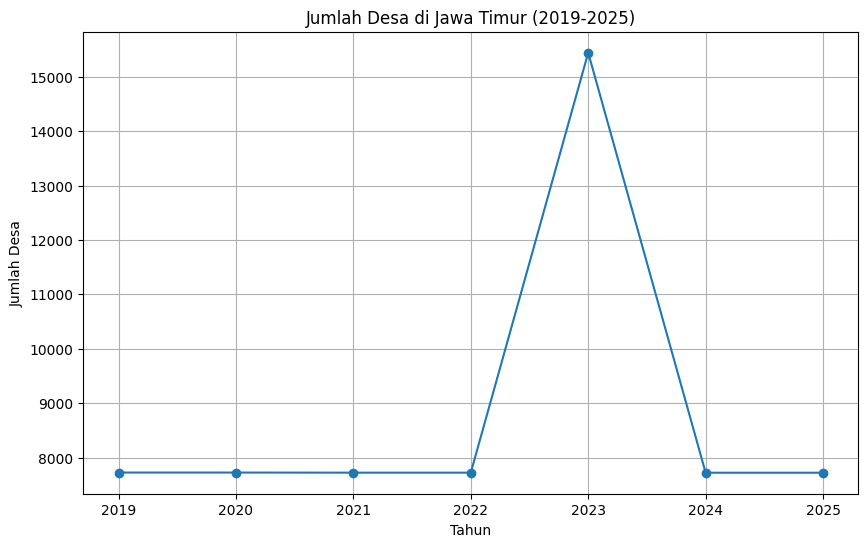

In [6]:
ts = data.groupby('tahun')['jumlah'].sum().reset_index()

plt.figure(figsize=(10,6))
plt.plot(ts['tahun'], ts['jumlah'], marker='o')
plt.title('Jumlah Desa di Jawa Timur (2019-2025)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Desa')
plt.grid(True)

plt.show()

# Check IQR

In [7]:
Q1 = data['jumlah'].quantile(0.25)
Q3 = data['jumlah'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier = data[
    (data['jumlah'] < lower_bound) |
    (data['jumlah'] > upper_bound)
]


if not outlier.empty:
    print("Terdapat outlier dalam data.")
    print("Outlier ditemukan pada nilai:")
    for i, row in outlier.iterrows():
        print(f"Kabupaten/Kota : {row['nama_kabupaten_kota']}")
        print(f"Jumlah          : {row['jumlah']}")
    # print(outlier['jumlah'].values)

else:
    print("Tidak terdapat outlier dalam data.")

Terdapat outlier dalam data.
Outlier ditemukan pada nilai:
Kabupaten/Kota : KABUPATEN PONOROGO
Jumlah          : 249
Kabupaten/Kota : KABUPATEN TULUNGAGUNG
Jumlah          : 196
Kabupaten/Kota : KOTA KEDIRI
Jumlah          : 258
Kabupaten/Kota : KOTA MALANG
Jumlah          : 182
Kabupaten/Kota : KOTA MALANG
Jumlah          : 170
Kabupaten/Kota : KOTA PROBOLINGGO
Jumlah          : 224
Kabupaten/Kota : KOTA PASURUAN
Jumlah          : 258
Kabupaten/Kota : KABUPATEN SIDOARJO
Jumlah          : 210
Kabupaten/Kota : KOTA MOJOKERTO
Jumlah          : 201
Kabupaten/Kota : KABUPATEN JOMBANG
Jumlah          : 244
Kabupaten/Kota : KABUPATEN NGANJUK
Jumlah          : 190
Kabupaten/Kota : KABUPATEN NGAWI
Jumlah          : 174
Kabupaten/Kota : KABUPATEN BOJONEGORO
Jumlah          : 322
Kabupaten/Kota : KABUPATEN TUBAN
Jumlah          : 217
Kabupaten/Kota : KABUPATEN LAMONGAN
Jumlah          : 328
Kabupaten/Kota : KABUPATEN GRESIK
Jumlah          : 220
Kabupaten/Kota : KABUPATEN BANGKALAN
Jumlah       

# Handling Outlier 

In [8]:
data_handling = data.copy()

data_handling.loc[
    data_handling['jumlah'] < lower_bound,
    'jumlah'
] = lower_bound

data_handling.loc[
    data_handling['jumlah'] > upper_bound,
    'jumlah'
] = upper_bound
data_handling[['nama_kabupaten_kota', 'jumlah']]

,nama_kabupaten_kota,jumlah
id,,
1,KABUPATEN PONOROGO,8
1,KABUPATEN PONOROGO,0
1,KABUPATEN PONOROGO,24
1,KABUPATEN PONOROGO,160
1,KABUPATEN PONOROGO,0
...,...,...
305,KOTA BATU,0
305,KOTA BATU,0
305,KOTA BATU,0


In [9]:
data_remove_outlier = data[
    (data['jumlah'] >= lower_bound) &
    (data['jumlah'] <= upper_bound)
]

data_remove_outlier =  data_remove_outlier.reset_index(drop=True)
print("\nJumlah data sebelum :", len(data))
print("Jumlah data sesudah :", len(data_remove_outlier))

print("\nData setelah remove outlier:")
data_remove_outlier[['nama_kabupaten_kota', 'jumlah']]


Jumlah data sebelum : 1525
Jumlah data sesudah : 1411

Data setelah remove outlier:


,nama_kabupaten_kota,jumlah
0,KABUPATEN PONOROGO,8
1,KABUPATEN PONOROGO,0
2,KABUPATEN PONOROGO,24
3,KABUPATEN PONOROGO,0
4,KABUPATEN TRENGGALEK,89
...,...,...
1406,KOTA BATU,0
1407,KOTA BATU,0
1408,KOTA BATU,0
1409,KOTA BATU,19


# Moving Average

Forecasting with MA 4

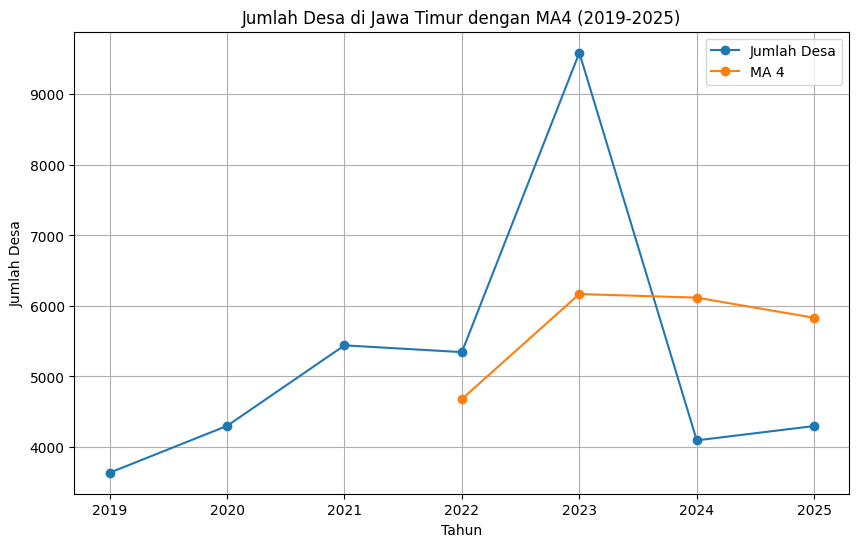

In [25]:
ts = data_remove_outlier.groupby('tahun')['jumlah'].sum().reset_index()
ts['ma4'] = ts['jumlah'].rolling(window=4).mean()

plt.figure(figsize=(10,6))
plt.plot(ts['tahun'], ts['jumlah'], marker='o', label='Jumlah Desa')
plt.plot(ts['tahun'], ts['ma4'], marker='o', label='MA 4')

plt.title('Jumlah Desa di Jawa Timur dengan MA4 (2019-2025)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Desa')
plt.grid(True)
plt.legend()
plt.show()

Forecasting with MA (6)

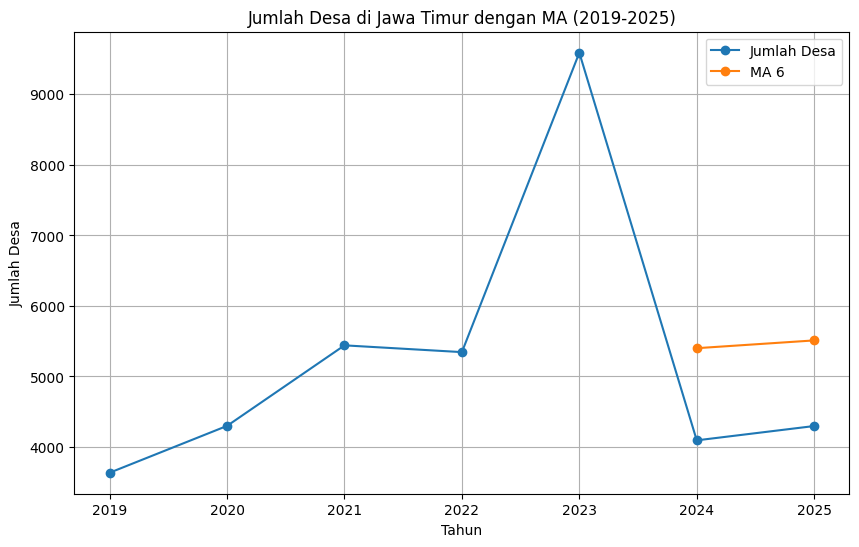

In [ ]:
ts = data_remove_outlier.groupby('tahun')['jumlah'].sum().reset_index()
ts['ma6'] = ts['jumlah'].rolling(window=6).mean()

plt.figure(figsize=(10,6))
plt.plot(ts['tahun'], ts['jumlah'], marker='o', label='Jumlah Desa')
plt.plot(ts['tahun'], ts['ma6'], marker='o', label='MA 6')

plt.title('Jumlah Desa di Jawa Timur dengan MA6 (2019-2025)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Desa')
plt.grid(True)
plt.legend()
plt.show()

Forecasting MA 12

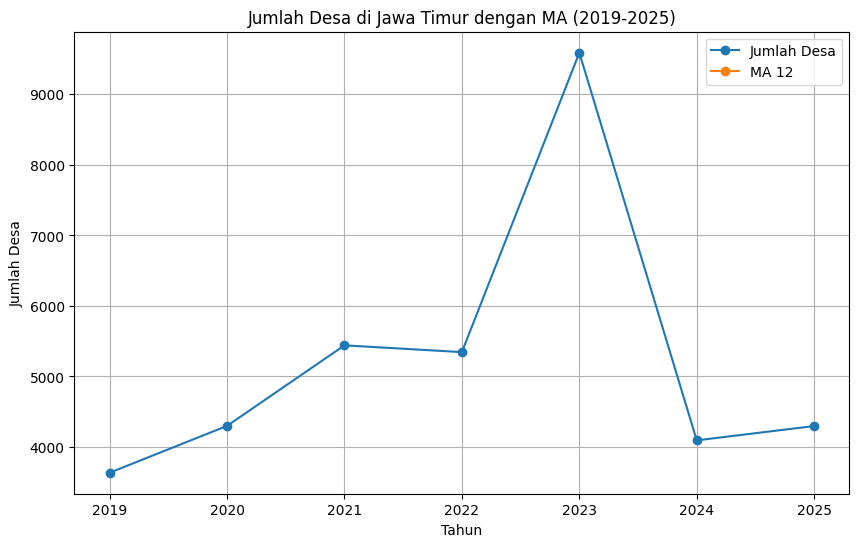

In [17]:
ts = data_remove_outlier.groupby('tahun')['jumlah'].sum().reset_index()
ts['ma12'] = ts['jumlah'].rolling(window=12).mean()

plt.figure(figsize=(10,6))
plt.plot(ts['tahun'], ts['jumlah'], marker='o', label='Jumlah Desa')
plt.plot(ts['tahun'], ts['ma12'], marker='o', label='MA 12')

plt.title('Jumlah Desa di Jawa Timur dengan MA (2019-2025)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Desa')
plt.grid(True)
plt.legend()
plt.show()

In [42]:
ts['ma4'] = ts['jumlah'].rolling(window=4).mean() 
ts['ma6'] = ts['jumlah'].rolling(window=6).mean() 
ts['ma12'] = ts['jumlah'].rolling(window=12).mean() 


# data_ramal = np.concatenate([ts['jumlah'], [ts['ma4'].iloc[-1]], [ts['ma6'].iloc[-1]], [ts['ma12'].iloc[-1]]])

data_ramal = ts['ma4']
data_ramal

0        NaN
1        NaN
2        NaN
3    4680.00
4    6168.75
5    6117.50
6    5831.50
Name: ma4, dtype: float64

mengabungkan data aktual,pemulusan, dan ramalan

In [43]:
import numpy as np
import pandas as pd

data_ma = ts['jumlah'].rolling(window=4).mean()

forecast = [data_ma.iloc[-1]] * 5

# buat dataframe
data = pd.DataFrame({
    'aktual': np.concatenate([
        ts['jumlah'],
        [np.nan]*5
    ]),
    
    'pemulusan': np.concatenate([
        data_ma,
        [np.nan]*5
    ]),
    
    'ramalan': np.concatenate([
        [np.nan]*len(ts['jumlah']),
        forecast
    ])
})

data

,aktual,pemulusan,ramalan
0,3635.0,NaN,NaN
1,4299.0,NaN,NaN
2,5441.0,NaN,NaN
3,5345.0,4680.00,NaN
4,9590.0,6168.75,NaN
5,4094.0,6117.50,NaN
6,4297.0,5831.50,NaN
7,NaN,NaN,5831.5
8,NaN,NaN,5831.5
9,NaN,NaN,5831.5


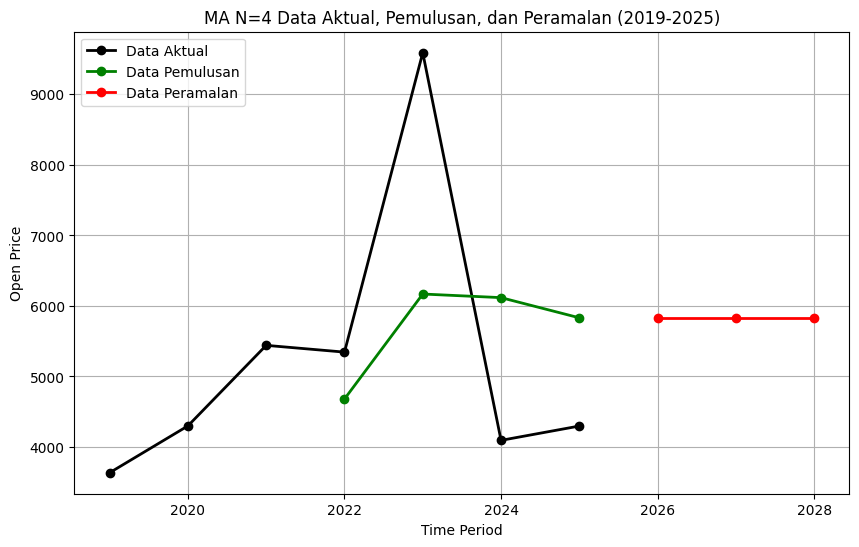

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# MA4
data_ma = ts['jumlah'].rolling(window=4).mean()

# forecast 3 periode
forecast = [data_ma.iloc[-1]] * 3

# tahun forecast
tahun_ramal = [2026, 2027, 2028]

plt.figure(figsize=(10,6))

# data aktual
plt.plot(ts['tahun'], ts['jumlah'],
         marker='o',
         color='black',
         linewidth=2,
         label='Data Aktual')

# data pemulusan
plt.plot(ts['tahun'], data_ma,
         marker='o',
         color='green',
         linewidth=2,
         label='Data Pemulusan')

# data ramalan
plt.plot(tahun_ramal, forecast,
         marker='o',
         color='red',
         linewidth=2,
         label='Data Peramalan')

plt.title('MA N=4 Data Aktual, Pemulusan, dan Peramalan (2019-2025)')
plt.xlabel('Time Period')
plt.ylabel('Open Price')

plt.legend(loc='upper left')
plt.grid(True)

plt.show()

Hitung SSE

In [46]:
import numpy as np

# error
error = ts['jumlah'] - data_ramal[:len(ts['jumlah'])]
SSE = np.sum(error[4:] ** 2)
print(SSE)

18154194.0625


Menghitung MSE dan MAPE

In [54]:
MSE = np.mean(error[5:len(ts['ma4'])] **2 )
MAPE = np.mean(abs((error[5:len(ts['ma4'])] / ts['jumlah'][5:len(ts['ma4'])]) * 100))

print("MSE:", MSE)
print("MAPE:", MAPE)

MSE: 3224621.25
MAPE: 42.56847519412039
